# BTUMQA-225K Phase 03D: Clean-Metadata QAdp-PRUGTM Shortcut, Bias, and Model Audit

This notebook audits whether the selected clean QAdp-PRUGTM-Hybrid model adds value beyond non-visual shortcut baselines.

It also evaluates Q-CUR calibrated confidence, review-flag usefulness, and residual failure concentration.

Interpretation rule: shortcut baselines are diagnostic tools, not deployable VQA systems.

## Dual Environment Compatibility Setup & Install Required Libraries


In [1]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

import importlib
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])


for import_name, pip_name in [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("sklearn", "scikit-learn"),
]:
    ensure_package(import_name, pip_name)

## Mount Google Drive and Configure Paths

In [2]:
from pathlib import Path
import os
import time

try:
    from google.colab import drive
#     drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Updated project path to point to the new drive structure
PROJECT_DRIVE_DIR = PROJECT_ROOT

# Corrected input paths: phase_3/p3a_brats_vqa_dataset/dataset_btumqa_225k
DATASET_DIR = PROJECT_DRIVE_DIR / "phase_3" / "p3a_brats_vqa_dataset" / "dataset_btumqa_225k"
BTUMQA_FULL_QA_PATH = DATASET_DIR / "btumqa_225k_qa_pairs.csv"

# Phase 5B final evaluation result directory
PHASE5B_RESULT_DIR = (
    PROJECT_DRIVE_DIR
    / "phase_5"
    / "p5b_final_evaluation_ablation_calibration"
    / "btumqa_225k_clean_metadata_four_seeds_final_comparison"
)
SELECTED_EVIDENCE_PATH = PHASE5B_RESULT_DIR / "explanation_ready" / "selected_model_test_structured_evidence.csv"
ALL_SEED_EVIDENCE_PATH = PHASE5B_RESULT_DIR / "explanation_ready" / "selected_model_all_seeds_test_structured_evidence.csv"

# Corrected result directory: phase_3/p3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline
RESULT_DIR = (
    PROJECT_DRIVE_DIR
    / "phase_3"
    / "p3d_qa_shortcut_bias_diagnostic_baselines"
    / "btumqa_225k_clean_metadata_shortcut_audit"
    / "qadp_prugtm_baseline"
)
TABLE_DIR = RESULT_DIR / "tables"
FIG_DIR = RESULT_DIR / "figures"
REPORT_DIR = RESULT_DIR / "reports"
PRED_DIR = RESULT_DIR / "predictions"
MODEL_DIR = RESULT_DIR / "models"
DONE_DIR = RESULT_DIR / "done"

for directory in [TABLE_DIR, FIG_DIR, REPORT_DIR, PRED_DIR, MODEL_DIR, DONE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Dataset:", BTUMQA_FULL_QA_PATH)
print("Selected evidence:", SELECTED_EVIDENCE_PATH)
print("All-seed evidence:", ALL_SEED_EVIDENCE_PATH)
print("Output dir:", RESULT_DIR)

Mounted at /content/drive
Dataset: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k/btumqa_225k_qa_pairs.csv
Selected evidence: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/selected_model_test_structured_evidence.csv
All-seed evidence: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/selected_model_all_seeds_test_structured_evidence.csv
Output dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_pru

## Imports, Helpers, and Baseline Policy

In [3]:
from __future__ import annotations

import hashlib
import json
import math
import os
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
sns.set_theme(style="whitegrid", context="notebook")


def now_string() -> str:
    return time.strftime("%Y-%m-%d %H:%M:%S")


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def save_json(obj: dict, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")
    return path


def save_table(df: pd.DataFrame, path: Path) -> pd.DataFrame:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    print(f"Saved {len(df):,} rows -> {path}")
    return df


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else float("nan")


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    table = pd.crosstab(x.fillna("__NA__").astype(str), y.fillna("__NA__").astype(str))
    if table.empty:
        return float("nan")
    obs = table.to_numpy(dtype=float)
    total = obs.sum()
    if total == 0:
        return float("nan")
    row_sum = obs.sum(axis=1, keepdims=True)
    col_sum = obs.sum(axis=0, keepdims=True)
    expected = row_sum @ col_sum / total
    mask = expected > 0
    chi2 = ((obs[mask] - expected[mask]) ** 2 / expected[mask]).sum()
    r, k = obs.shape
    denom = total * max(min(k - 1, r - 1), 1)
    return float(math.sqrt(chi2 / denom))


def normalized_entropy(series: pd.Series) -> float:
    counts = series.fillna("__NA__").astype(str).value_counts(normalize=True)
    if len(counts) <= 1:
        return 0.0
    entropy = -float((counts * np.log2(counts)).sum())
    return entropy / math.log2(len(counts))


def dominance_summary(df: pd.DataFrame, group_col: str, label_col: str = "answer") -> pd.DataFrame:
    rows = []
    for value, sub in df.groupby(group_col, dropna=False):
        label_counts = sub[label_col].fillna("__NA__").astype(str).value_counts()
        top_label = label_counts.index[0] if len(label_counts) else ""
        top_count = int(label_counts.iloc[0]) if len(label_counts) else 0
        rows.append(
            {
                "group_column": group_col,
                "group_value": value,
                "rows": int(len(sub)),
                "unique_answers": int(label_counts.size),
                "top_answer": top_label,
                "top_answer_count": top_count,
                "top_answer_share": safe_div(top_count, len(sub)),
                "answer_entropy_normalized": normalized_entropy(sub[label_col]),
            }
        )
    return pd.DataFrame(rows).sort_values(["top_answer_share", "rows"], ascending=[False, False])

import pickle

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


RANDOM_STATE = 42
CLEAN_SAFE_FEATURE_COLUMNS = [
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
]
REGIONS = ["edema", "ncr_net", "enhancing", "tumor", "context", "global"]
AREA_COLUMNS = [f"{region}_area_pixels" for region in REGIONS]
UNCERTAINTY_COLUMNS = [f"{region}_uncertainty" for region in REGIONS]
WEIGHT_COLUMNS = [f"{region}_weight" for region in REGIONS]
FORBIDDEN_AUDIT_ONLY_FEATURE_COLUMNS = (
    AREA_COLUMNS
    + UNCERTAINTY_COLUMNS
    + WEIGHT_COLUMNS
    + [
        "decision_rule_id",
        "label_provenance",
        "candidate_keep_reason",
        "mc_dropout_passes",
    ]
)
SLICE_COLUMNS = [
    "question_family",
    "question_style",
    "difficulty_level",
    "ambiguity_flag",
    "signal_gap_bucket",
    "region_target_primary",
    "region_target_secondary",
    "target_region_uncertainty_level",
    "review_flag",
]


def compute_metrics(y_true, y_pred) -> dict:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    }


def metrics_row(model_key: str, model_label: str, split: str, y_true, y_pred, source: str, policy_group: str) -> dict:
    row = {
        "model_key": model_key,
        "model_label": model_label,
        "split": split,
        "source": source,
        "policy_group": policy_group,
        "rows": int(len(y_true)),
    }
    row.update(compute_metrics(y_true, y_pred))
    return row


def evaluate_by_slice(frame: pd.DataFrame, pred_col: str, model_key: str, model_label: str, source: str, policy_group: str) -> pd.DataFrame:
    rows = []
    for col in [c for c in SLICE_COLUMNS if c in frame.columns]:
        for value, sub in frame.groupby(col, dropna=False):
            if len(sub) < 20:
                continue
            row = {
                "model_key": model_key,
                "model_label": model_label,
                "source": source,
                "policy_group": policy_group,
                "slice_column": col,
                "slice_value": value,
                "rows": int(len(sub)),
            }
            row.update(compute_metrics(sub["answer"], sub[pred_col]))
            rows.append(row)
    return pd.DataFrame(rows)


baseline_policy = pd.DataFrame(
    [
        {
            "model_key": "majority_answer",
            "policy_group": "diagnostic_clean_safe",
            "description": "Majority answer prior from train split.",
        },
        {
            "model_key": "question_family_majority",
            "policy_group": "diagnostic_clean_safe",
            "description": "Question-family-specific train majority answer.",
        },
        {
            "model_key": "question_text_tfidf_logreg",
            "policy_group": "diagnostic_clean_safe",
            "description": "Question text only; measures answer recoverability from wording.",
        },
        {
            "model_key": "clean_safe_descriptor_logreg",
            "policy_group": "diagnostic_clean_safe",
            "description": "Question-visible descriptors only; no raw area/uncertainty/weight fields.",
        },
        {
            "model_key": "forbidden_audit_metadata_logreg",
            "policy_group": "forbidden_audit_only",
            "description": "Answer-proximal metadata fields; invalid as final model input and used only to quantify shortcut risk.",
        },
    ]
)
save_table(baseline_policy, TABLE_DIR / "phase03d_clean_shortcut_baseline_policy.csv")
baseline_policy

Saved 5 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/tables/phase03d_clean_shortcut_baseline_policy.csv


,model_key,policy_group,description
0,majority_answer,diagnostic_clean_safe,Majority answer prior from train split.
1,question_family_majority,diagnostic_clean_safe,Question-family-specific train majority answer.
2,question_text_tfidf_logreg,diagnostic_clean_safe,Question text only; measures answer recoverabi...
3,clean_safe_descriptor_logreg,diagnostic_clean_safe,Question-visible descriptors only; no raw area...
4,forbidden_audit_metadata_logreg,forbidden_audit_only,Answer-proximal metadata fields; invalid as fi...


## Load Dataset and Selected QAdp Evidence

In [4]:
if not BTUMQA_FULL_QA_PATH.exists():
    raise FileNotFoundError(f"BTUMQA CSV not found: {BTUMQA_FULL_QA_PATH}")
if not SELECTED_EVIDENCE_PATH.exists():
    raise FileNotFoundError(f"Selected evidence CSV not found: {SELECTED_EVIDENCE_PATH}")

dtype_cols = {col: str for col in ["qa_id", "patient_id", "slice_id", "unique_id", "image_id"]}
df = pd.read_csv(BTUMQA_FULL_QA_PATH, dtype=dtype_cols)
evidence = pd.read_csv(SELECTED_EVIDENCE_PATH, dtype={"qa_id": str, "unique_id": str})

if "answer" not in df.columns:
    raise ValueError("Dataset must contain answer column.")
if "gold_answer" in evidence.columns and "answer" not in evidence.columns:
    evidence = evidence.rename(columns={"gold_answer": "answer"})
if "predicted_answer" not in evidence.columns:
    raise ValueError("Selected evidence must contain predicted_answer.")

train_df = df[df["split"] == "train"].copy()
val_df = df[df["split"] == "val"].copy()
test_df = df[df["split"] == "test"].copy()

if "qa_id" in evidence.columns:
    test_eval = test_df.merge(
        evidence.drop(columns=[c for c in ["question", "answer"] if c in evidence.columns], errors="ignore"),
        on=["qa_id", "unique_id"],
        how="inner",
        suffixes=("", "_evidence"),
    )
else:
    raise ValueError("Selected evidence must contain qa_id for reliable joins.")

if len(test_eval) != len(evidence):
    print(f"Warning: joined rows {len(test_eval):,} differ from selected evidence rows {len(evidence):,}.")

test_eval["qadp_pred"] = test_eval["predicted_answer"].astype(str)
test_eval["answer"] = test_eval["answer"].astype(str)
test_eval["qadp_correct"] = test_eval["answer"] == test_eval["qadp_pred"]

manifest = {
    "phase": "Phase 03D clean-metadata shortcut and QAdp model audit",
    "created_at": now_string(),
    "dataset_path": str(BTUMQA_FULL_QA_PATH),
    "dataset_sha256": sha256_file(BTUMQA_FULL_QA_PATH),
    "selected_evidence_path": str(SELECTED_EVIDENCE_PATH),
    "selected_evidence_sha256": sha256_file(SELECTED_EVIDENCE_PATH),
    "dataset_rows": int(len(df)),
    "selected_evidence_rows": int(len(evidence)),
    "joined_test_rows": int(len(test_eval)),
    "output_dir": str(RESULT_DIR),
}
save_json(manifest, REPORT_DIR / "phase03d_clean_qadp_audit_reproducibility_manifest.json")

print(f"Train rows: {len(train_df):,} | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}")
print(f"Selected evidence rows: {len(evidence):,} | Joined rows: {len(test_eval):,}")
display(test_eval.head())

Train rows: 157,500 | Val rows: 33,750 | Test rows: 33,750
Selected evidence rows: 33,750 | Joined rows: 33,750


,qa_id,split,patient_id,slice_id,unique_id,image_id,question,answer,answer_type,question_family,template_id,paraphrase_id,dataset_branch,question_style,difficulty_level,ambiguity_flag,region_target_primary,region_target_secondary,signal_gap_bucket,decision_rule_id,label_provenance,candidate_keep_reason,modality_context,tumor_slice_csv,edema_area_pixels,ncr_net_area_pixels,enhancing_area_pixels,tumor_area_pixels,context_area_pixels,global_area_pixels,edema_uncertainty,ncr_net_uncertainty,enhancing_uncertainty,tumor_uncertainty,context_uncertainty,global_uncertainty,edema_weight,ncr_net_weight,enhancing_weight,tumor_weight,context_weight,global_weight,phase2a_token_file,slice_index_in_token_file,phase2c_file,slice_index_in_ugtm_file,mc_dropout_passes,split_evidence,seed,model_key,model_label,question_family_evidence,question_style_evidence,predicted_answer,is_correct,raw_confidence,posthoc_confidence,qcur_confidence,target_region,comparison_region,target_region_uncertainty,comparison_region_uncertainty,uncertainty_gap,target_region_uncertainty_level,target_region_weight,target_region_area_pixels,aux_gate_mean,attended_uncertainty,low_confidence_flag,high_uncertainty_flag,calibration_drop_flag,review_flag,review_reason,review_template_text,ambiguity_flag_evidence,signal_gap_bucket_evidence,region_target_primary_evidence,region_target_secondary_evidence,region_target_pair,qadp_pred,qadp_correct
0,BTUMQA225K_07a3eda3b59c63,test,00002,033,00002_033,033,"Is edema confidently present, uncertainly pres...",not_present,classification,confidence_qualified_presence,confidence_qualified_presence_template_02,confidence_qualified_presence_paraphrase_02,btumqa_225k,confidence_qualified,easy,no,edema,NaN,wide_gap,confidence_qualified_presence_v1,phase1_pseudo_mask+phase2b_uncertainty,balanced_family_sampling,FLAIR|T1|T1ce|T2,0,0,0,0,0,0,5663,0.0,0.0,0.0,0.0,0.0,2.300000e-07,1.0,1.0,1.0,1.0,1.0,1.000000,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,20,test,seed_1337,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,confidence_qualified_presence,confidence_qualified,not_present,1,0.936464,0.988856,0.995073,edema,NaN,0.000000e+00,NaN,NaN,low,1.000000,0.0,0.532916,0.0,False,False,False,False,available confidence and uncertainty evidence ...,The model predicts not_present with 1.00 calib...,no,wide_gap,edema,NaN,edema|none,not_present,True
1,BTUMQA225K_668ac232b10861,test,00002,033,00002_033,033,Which region is safest to trust for reasoning ...,global,classification,safe_region_for_reasoning,safe_region_for_reasoning_template_01,safe_region_for_reasoning_paraphrase_01,btumqa_225k,ranking,easy,no,global,NaN,wide_gap,safe_region_for_reasoning_v1,phase2a_area+phase2c_weight,balanced_family_sampling,FLAIR|T1|T1ce|T2,0,0,0,0,0,0,5663,0.0,0.0,0.0,0.0,0.0,2.300000e-07,1.0,1.0,1.0,1.0,1.0,1.000000,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,20,test,seed_1337,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,safe_region_for_reasoning,ranking,global,1,0.968307,0.991442,0.999548,global,NaN,2.300000e-07,NaN,NaN,low,1.000000,5663.0,0.581184,0.0,False,False,False,False,available confidence and uncertainty evidence ...,The model predicts global with 1.00 calibrated...,no,wide_gap,global,NaN,global|none,global,True
2,BTUMQA225K_f1d4b092590518,test,00002,033,00002_033,033,Which confidence-qualified extent label best f...,none,classification,confidence_qualified_extent,confidence_qualified_extent_template_03,confidence_qualified_extent_paraphrase_03,btumqa_225k,confidence_qualified,easy,no,tumor,NaN,wide_gap,confidence_qualified_extent_v1,phase1_pseudo_mask+phase2b_uncertainty,balanced_family_sampling,FLAIR|T1|T1ce|T2,0,0,0,0,0,0,5663,0.0,0.0,0.0,0.0,0.0,2.300000e-07,1.0,1.0,1.0,1.0,1.0,1.000000,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,20,test,seed_1337,qadp_prugtm_hybrid_clean,QAdp-PRUGTM-Hybrid,con

## Train Diagnostic Shortcut Baselines

In [5]:
baseline_predictions = pd.DataFrame(
    {
        "qa_id": test_df["qa_id"].astype(str).values,
        "unique_id": test_df["unique_id"].astype(str).values,
        "answer": test_df["answer"].astype(str).values,
    }
)

trained_models = {}

# Majority answer baseline.
majority_model = DummyClassifier(strategy="most_frequent")
majority_model.fit(train_df[["question"]], train_df["answer"].astype(str))
baseline_predictions["majority_answer_pred"] = majority_model.predict(test_df[["question"]])
trained_models["majority_answer"] = majority_model

# Question-family majority answer baseline.
global_majority = train_df["answer"].astype(str).mode().iloc[0]
family_majority = train_df.groupby("question_family")["answer"].agg(lambda s: s.astype(str).mode().iloc[0]).to_dict()
baseline_predictions["question_family_majority_pred"] = test_df["question_family"].map(family_majority).fillna(global_majority).astype(str).values

# Question text-only TF-IDF logistic regression.
text_model = Pipeline(
    [
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    ]
)
text_model.fit(train_df["question"].fillna("").astype(str), train_df["answer"].astype(str))
baseline_predictions["question_text_tfidf_logreg_pred"] = text_model.predict(test_df["question"].fillna("").astype(str))
trained_models["question_text_tfidf_logreg"] = text_model

# Clean-safe descriptor logistic regression.
clean_safe_cols = [c for c in CLEAN_SAFE_FEATURE_COLUMNS if c in train_df.columns]
clean_safe_model = Pipeline(
    [
        ("prep", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="ignore"), clean_safe_cols)])),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    ]
)
clean_safe_model.fit(train_df[clean_safe_cols].fillna("__NA__"), train_df["answer"].astype(str))
baseline_predictions["clean_safe_descriptor_logreg_pred"] = clean_safe_model.predict(test_df[clean_safe_cols].fillna("__NA__"))
trained_models["clean_safe_descriptor_logreg"] = clean_safe_model

# Forbidden audit-only metadata logistic regression.
forbidden_cols = [c for c in FORBIDDEN_AUDIT_ONLY_FEATURE_COLUMNS if c in train_df.columns]
numeric_forbidden_cols = [c for c in forbidden_cols if c in AREA_COLUMNS + UNCERTAINTY_COLUMNS + WEIGHT_COLUMNS + ["mc_dropout_passes"]]
categorical_forbidden_cols = [c for c in forbidden_cols if c not in numeric_forbidden_cols]
forbidden_preprocess = ColumnTransformer(
    [
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric_forbidden_cols),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_forbidden_cols),
    ]
)
forbidden_model = Pipeline(
    [
        ("prep", forbidden_preprocess),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)),
    ]
)
forbidden_model.fit(train_df[forbidden_cols], train_df["answer"].astype(str))
baseline_predictions["forbidden_audit_metadata_logreg_pred"] = forbidden_model.predict(test_df[forbidden_cols])
trained_models["forbidden_audit_metadata_logreg"] = forbidden_model

prediction_path = PRED_DIR / "phase03d_clean_shortcut_baseline_predictions.csv"
baseline_predictions.to_csv(prediction_path, index=False)
with open(MODEL_DIR / "phase03d_clean_shortcut_baseline_models.pkl", "wb") as f:
    pickle.dump(trained_models, f)

print("Saved baseline predictions:", prediction_path)
display(baseline_predictions.head())

Saved baseline predictions: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/predictions/phase03d_clean_shortcut_baseline_predictions.csv


,qa_id,unique_id,answer,majority_answer_pred,question_family_majority_pred,question_text_tfidf_logreg_pred,clean_safe_descriptor_logreg_pred,forbidden_audit_metadata_logreg_pred
0,BTUMQA225K_07a3eda3b59c63,00002_033,not_present,edema,confident_present,confident_present,not_present,not_present
1,BTUMQA225K_668ac232b10861,00002_033,global,edema,tumor,global,global,global
2,BTUMQA225K_f1d4b092590518,00002_033,none,edema,large_confident,small_confident,none,none
3,BTUMQA225K_c2e575cfe72f68,00002_034,global,edema,tumor,global,global,global
4,BTUMQA225K_142f3c4ec5e345,00002_035,not_present,edema,confident_present,confident_present,not_present,not_present


## Overall Baseline vs QAdp Metrics

In [6]:
prediction_join = test_eval.merge(
    baseline_predictions.drop(columns=["answer"], errors="ignore"),
    on=["qa_id", "unique_id"],
    how="left",
)

overall_rows = []
baseline_specs = [
    ("majority_answer", "Majority Answer", "majority_answer_pred", "non_visual_shortcut", "diagnostic_clean_safe"),
    ("question_family_majority", "Question-Family Majority", "question_family_majority_pred", "non_visual_shortcut", "diagnostic_clean_safe"),
    ("question_text_tfidf_logreg", "Question Text TF-IDF LogReg", "question_text_tfidf_logreg_pred", "non_visual_shortcut", "diagnostic_clean_safe"),
    ("clean_safe_descriptor_logreg", "Clean-Safe Descriptor LogReg", "clean_safe_descriptor_logreg_pred", "non_visual_shortcut", "diagnostic_clean_safe"),
    ("forbidden_audit_metadata_logreg", "Forbidden Audit Metadata LogReg", "forbidden_audit_metadata_logreg_pred", "forbidden_metadata_diagnostic", "forbidden_audit_only"),
    ("qadp_prugtm_hybrid_qcur", "QAdp-PRUGTM-Hybrid + Q-CUR", "qadp_pred", "selected_clean_model", "final_clean_model"),
]
for key, label, pred_col, source, policy_group in baseline_specs:
    overall_rows.append(metrics_row(key, label, "test", prediction_join["answer"], prediction_join[pred_col], source, policy_group))

overall_table = save_table(pd.DataFrame(overall_rows).sort_values("macro_f1", ascending=False), TABLE_DIR / "phase03d_clean_shortcut_vs_qadp_overall_metrics.csv")

non_visual = overall_table[overall_table["source"].isin(["non_visual_shortcut", "forbidden_metadata_diagnostic"])].copy()
best_clean_safe = overall_table.query("policy_group == 'diagnostic_clean_safe'").sort_values("macro_f1", ascending=False).head(1)
qadp_row = overall_table.query("model_key == 'qadp_prugtm_hybrid_qcur'").iloc[0]

gap_rows = []
for metric in ["accuracy", "macro_f1", "weighted_f1"]:
    gap_rows.append(
        {
            "metric": metric,
            "qadp_value": float(qadp_row[metric]),
            "best_clean_safe_shortcut_value": float(best_clean_safe.iloc[0][metric]),
            "qadp_minus_best_clean_safe_shortcut": float(qadp_row[metric] - best_clean_safe.iloc[0][metric]),
        }
    )
shortcut_gap_table = save_table(pd.DataFrame(gap_rows), TABLE_DIR / "phase03d_clean_qadp_shortcut_gap_overall.csv")

display(overall_table)
display(shortcut_gap_table)

Saved 6 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/tables/phase03d_clean_shortcut_vs_qadp_overall_metrics.csv
Saved 3 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/tables/phase03d_clean_qadp_shortcut_gap_overall.csv


,model_key,model_label,split,source,policy_group,rows,accuracy,macro_f1,weighted_f1
5,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,test,selected_clean_model,final_clean_model,33750,0.929274,0.920041,0.931475
4,forbidden_audit_metadata_logreg,Forbidden Audit Metadata LogReg,test,forbidden_metadata_diagnostic,forbidden_audit_only,33750,0.708326,0.825535,0.706215
3,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,test,non_visual_shortcut,diagnostic_clean_safe,33750,0.879348,0.746961,0.868426
2,question_text_tfidf_logreg,Question Text TF-IDF LogReg,test,non_visual_shortcut,diagnostic_clean_safe,33750,0.365037,0.269463,0.373308
1,question_family_majority,Question-Family Majority,test,non_visual_shortcut,diagnostic_clean_safe,33750,0.460504,0.214158,0.392384
0,majority_answer,Majority Answer,test,non_visual_shortcut,diagnostic_clean_safe,33750,0.108830,0.008535,0.021363


,metric,qadp_value,best_clean_safe_shortcut_value,qadp_minus_best_clean_safe_shortcut
0,accuracy,0.929274,0.879348,0.049926
1,macro_f1,0.920041,0.746961,0.173080
2,weighted_f1,0.931475,0.868426,0.063049


## Slice-Level Bias and Shortcut-Gap Diagnostics

In [7]:
slice_tables = []
for key, label, pred_col, source, policy_group in baseline_specs:
    slice_tables.append(evaluate_by_slice(prediction_join, pred_col, key, label, source, policy_group))
slice_table = save_table(pd.concat(slice_tables, ignore_index=True), TABLE_DIR / "phase03d_clean_shortcut_vs_qadp_slice_metrics.csv")

qadp_slices = slice_table.query("model_key == 'qadp_prugtm_hybrid_qcur'").copy()
clean_safe_slices = slice_table.query("policy_group == 'diagnostic_clean_safe'").copy()
best_clean_safe_slice = (
    clean_safe_slices.sort_values("macro_f1", ascending=False)
    .groupby(["slice_column", "slice_value"], as_index=False)
    .first()
    .rename(columns={"model_key": "best_clean_safe_model_key", "model_label": "best_clean_safe_model_label", "accuracy": "best_clean_safe_accuracy", "macro_f1": "best_clean_safe_macro_f1", "weighted_f1": "best_clean_safe_weighted_f1"})
)
shortcut_gap_by_slice = qadp_slices.merge(
    best_clean_safe_slice[["slice_column", "slice_value", "best_clean_safe_model_key", "best_clean_safe_model_label", "best_clean_safe_accuracy", "best_clean_safe_macro_f1", "best_clean_safe_weighted_f1"]],
    on=["slice_column", "slice_value"],
    how="left",
)
shortcut_gap_by_slice["qadp_minus_best_clean_safe_accuracy"] = shortcut_gap_by_slice["accuracy"] - shortcut_gap_by_slice["best_clean_safe_accuracy"]
shortcut_gap_by_slice["qadp_minus_best_clean_safe_macro_f1"] = shortcut_gap_by_slice["macro_f1"] - shortcut_gap_by_slice["best_clean_safe_macro_f1"]
shortcut_gap_by_slice["qadp_minus_best_clean_safe_weighted_f1"] = shortcut_gap_by_slice["weighted_f1"] - shortcut_gap_by_slice["best_clean_safe_weighted_f1"]
shortcut_gap_by_slice = save_table(
    shortcut_gap_by_slice.sort_values("qadp_minus_best_clean_safe_macro_f1"),
    TABLE_DIR / "phase03d_clean_qadp_shortcut_gap_by_slice.csv",
)

display(shortcut_gap_by_slice.head(20))
display(shortcut_gap_by_slice.tail(20))

Saved 252 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/tables/phase03d_clean_shortcut_vs_qadp_slice_metrics.csv
Saved 42 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/tables/phase03d_clean_qadp_shortcut_gap_by_slice.csv


,model_key,model_label,source,policy_group,slice_column,slice_value,rows,accuracy,macro_f1,weighted_f1,best_clean_safe_model_key,best_clean_safe_model_label,best_clean_safe_accuracy,best_clean_safe_macro_f1,best_clean_safe_weighted_f1,qadp_minus_best_clean_safe_accuracy,qadp_minus_best_clean_safe_macro_f1,qadp_minus_best_clean_safe_weighted_f1
25,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,region_target_primary,context,2223,0.932973,0.193065,0.965325,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.067027,-0.806935,-0.034675
17,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,difficulty_level,easy,8554,0.972761,0.609978,0.983968,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.934183,0.928353,0.936720,0.038578,-0.318375,0.047248
24,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,signal_gap_bucket,wide_gap,8554,0.972761,0.609978,0.983968,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.934183,0.928353,0.936720,0.038578,-0.318375,0.047248
41,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,review_flag,True,2903,0.516707,0.500691,0.447197,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.965553,0.769537,0.958953,-0.448846,-0.268846,-0.511756
32,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,region_target_secondary,edema,4981,0.963662,0.755904,0.977624,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.036338,-0.244096,-0.022376
27,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,region_target_primary,enhancing,5985,0.905764,0.699749,0.922205,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.905263,0.918454,0.911083,0.000501,-0.218705,0.011122
8,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,question_family,reliability_gap_bucket,2700,0.847407,0.800269,0.851338,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.152593,-0.199731,-0.148662
22,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,signal_gap_bucket,close_gap,11377,0.889426,0.505260,0.914366,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.843544,0.703112,0.825462,0.045882,-0.197852,0.088904
21,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,ambiguity_flag,yes,11377,0.889426,0.505260,0.914366,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.843544,0.703112,0.825462,0.045882,-0.197852,0.088904
13,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,question_style,bucketed,5400,0.845185,0.809008,0.849143,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.154815,-0.190992,-0.150857


,model_key,model_label,source,policy_group,slice_column,slice_value,rows,accuracy,macro_f1,weighted_f1,best_clean_safe_model_key,best_clean_safe_model_label,best_clean_safe_accuracy,best_clean_safe_macro_f1,best_clean_safe_weighted_f1,qadp_minus_best_clean_safe_accuracy,qadp_minus_best_clean_safe_macro_f1,qadp_minus_best_clean_safe_weighted_f1
4,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,question_family,highest_risk_region,2532,0.919431,0.931337,0.919596,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.080569,-0.068663,-0.080404
33,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,region_target_secondary,enhancing,7295,0.898149,0.852966,0.902495,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.924058,0.919768,0.911790,-0.025908,-0.066801,-0.009294
16,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,question_style,ranking,7764,0.938434,0.941784,0.938485,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.061566,-0.058216,-0.061515
9,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,question_family,safe_region_for_reasoning,2700,0.990741,0.963584,0.990694,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.009259,-0.036416,-0.009306
2,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,question_family,confidence_qualified_presence,2532,0.966825,0.966880,0.966897,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.033175,-0.033120,-0.033103
3,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,question_family,dominant_region_under_uncertainty,3374,0.972733,0.972002,0.972696,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,-0.027267,-0.027998,-0.027304
28,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,region_target_primary,global,503,1.000000,1.000000,1.000000,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
26,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,region_target_primary,edema,12553,0.941050,0.917244,0.942530,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.912292,0.886001,0.917842,0.028758,0.031243,0.024688
37,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,target_region_uncertainty_level,high,8438,0.888836,0.845055,0.887046,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.840602,0.809447,0.825142,0.048234,0.035607,0.061904
35,qadp_prugtm_hybrid_qcur,QAdp-PRUGTM-Hybrid + Q-CUR,selected_clean_model,final_clean_model,region_target_secondary,tumor,5780,0.920934,0.906790,0.921740,clean_safe_descriptor_logreg,Clean-Safe Descriptor LogReg,0.848616,0.842828,0.851279,0.072318,0.063962,0.070462


## Error Concentration, Confidence, and Review-Flag Usefulness

In [8]:
error_rows = []
for col in [c for c in SLICE_COLUMNS if c in prediction_join.columns]:
    for value, sub in prediction_join.groupby(col, dropna=False):
        if len(sub) < 20:
            continue
        error_rows.append(
            {
                "slice_column": col,
                "slice_value": value,
                "rows": int(len(sub)),
                "qadp_errors": int((~sub["qadp_correct"]).sum()),
                "qadp_error_rate": float((~sub["qadp_correct"]).mean()),
                "mean_qcur_confidence": float(pd.to_numeric(sub.get("qcur_confidence"), errors="coerce").mean()) if "qcur_confidence" in sub.columns else float("nan"),
                "mean_raw_confidence": float(pd.to_numeric(sub.get("raw_confidence"), errors="coerce").mean()) if "raw_confidence" in sub.columns else float("nan"),
            }
        )
error_concentration_table = save_table(
    pd.DataFrame(error_rows).sort_values(["qadp_error_rate", "rows"], ascending=[False, False]),
    TABLE_DIR / "phase03d_clean_qadp_error_concentration.csv",
)

confidence_rows = []
for correctness, sub in prediction_join.groupby("qadp_correct"):
    confidence_rows.append(
        {
            "qadp_correct": bool(correctness),
            "rows": int(len(sub)),
            "raw_confidence_mean": float(pd.to_numeric(sub.get("raw_confidence"), errors="coerce").mean()),
            "raw_confidence_median": float(pd.to_numeric(sub.get("raw_confidence"), errors="coerce").median()),
            "qcur_confidence_mean": float(pd.to_numeric(sub.get("qcur_confidence"), errors="coerce").mean()),
            "qcur_confidence_median": float(pd.to_numeric(sub.get("qcur_confidence"), errors="coerce").median()),
        }
    )
confidence_table = save_table(pd.DataFrame(confidence_rows), TABLE_DIR / "phase03d_clean_qadp_confidence_by_correctness.csv")

review_rows = []
if "review_flag" in prediction_join.columns:
    prediction_join["review_flag_bool"] = prediction_join["review_flag"].astype(str).str.lower().isin(["true", "1", "yes"])
    for flag, sub in prediction_join.groupby("review_flag_bool"):
        review_rows.append(
            {
                "review_flag": bool(flag),
                "rows": int(len(sub)),
                "row_share": float(len(sub) / len(prediction_join)),
                "qadp_error_rate": float((~sub["qadp_correct"]).mean()),
                "mean_qcur_confidence": float(pd.to_numeric(sub.get("qcur_confidence"), errors="coerce").mean()),
                "high_uncertainty_share": float(sub.get("high_uncertainty_flag", pd.Series(False, index=sub.index)).astype(str).str.lower().isin(["true", "1", "yes"]).mean()),
                "low_confidence_share": float(sub.get("low_confidence_flag", pd.Series(False, index=sub.index)).astype(str).str.lower().isin(["true", "1", "yes"]).mean()),
                "calibration_drop_share": float(sub.get("calibration_drop_flag", pd.Series(False, index=sub.index)).astype(str).str.lower().isin(["true", "1", "yes"]).mean()),
                "ambiguity_yes_share": float((sub.get("ambiguity_flag", pd.Series("", index=sub.index)).astype(str).str.lower() == "yes").mean()),
                "close_gap_share": float((sub.get("signal_gap_bucket", pd.Series("", index=sub.index)).astype(str) == "close_gap").mean()),
            }
        )
    review_flag_table = save_table(pd.DataFrame(review_rows), TABLE_DIR / "phase03d_clean_review_flag_usefulness.csv")
else:
    review_flag_table = pd.DataFrame()

display(error_concentration_table.head(20))
display(confidence_table)
display(review_flag_table)

Saved 42 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/tables/phase03d_clean_qadp_error_concentration.csv
Saved 2 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/tables/phase03d_clean_qadp_confidence_by_correctness.csv
Saved 2 rows -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/tables/phase03d_clean_review_flag_usefulness.csv


,slice_column,slice_value,rows,qadp_errors,qadp_error_rate,mean_qcur_confidence,mean_raw_confidence
41,review_flag,True,2903,1403,0.483293,0.521726,0.584480
11,question_family,uncertainty_gap_bucket,2700,424,0.157037,0.880011,0.756467
13,question_style,bucketed,5400,836,0.154815,0.877767,0.753763
8,question_family,reliability_gap_bucket,2700,412,0.152593,0.875523,0.751060
37,target_region_uncertainty_level,high,8438,938,0.111164,0.898681,0.785161
21,ambiguity_flag,yes,11377,1258,0.110574,0.912995,0.765595
22,signal_gap_bucket,close_gap,11377,1258,0.110574,0.912995,0.765595
18,difficulty_level,hard,11374,1237,0.108757,0.909638,0.764329
0,question_family,ambiguous_subregion_pair,3374,359,0.106402,0.890144,0.779537
33,region_target_secondary,enhancing,7295,743,0.101851,0.901994,0.759360


,qadp_correct,rows,raw_confidence_mean,raw_confidence_median,qcur_confidence_mean,qcur_confidence_median
0,False,2387,0.629626,0.608932,0.631872,0.701561
1,True,31363,0.806110,0.811290,0.955409,0.986472


,review_flag,rows,row_share,qadp_error_rate,mean_qcur_confidence,high_uncertainty_share,low_confidence_share,calibration_drop_share,ambiguity_yes_share,close_gap_share
0,False,30847,0.913985,0.031899,0.971187,0.223296,0.000000,0.000000,0.327228,0.327228
1,True,2903,0.086015,0.483293,0.521726,0.533930,0.773338,0.346883,0.441957,0.441957


## Figures

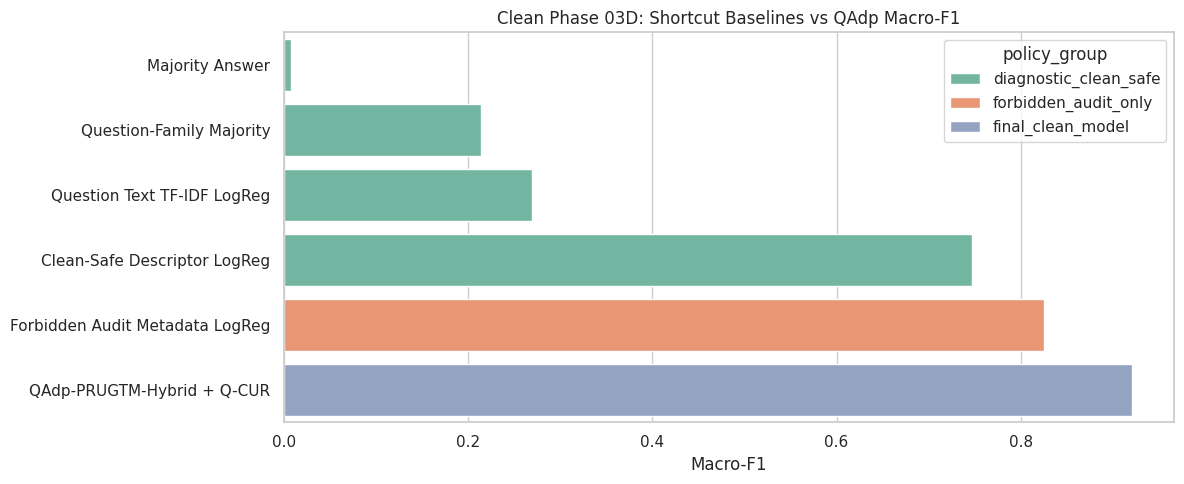

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/figures/phase03d_clean_shortcut_vs_qadp_macro_f1.png


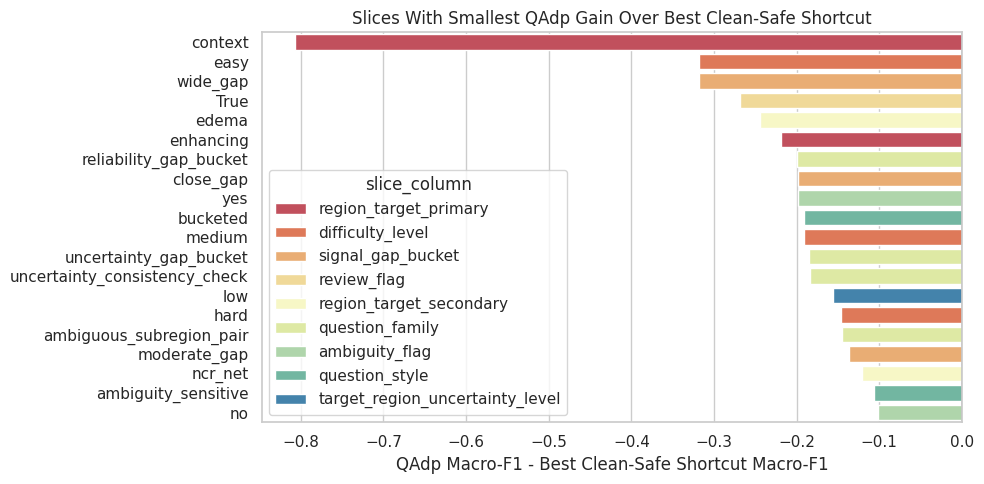

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/figures/phase03d_clean_lowest_qadp_shortcut_gap_slices.png


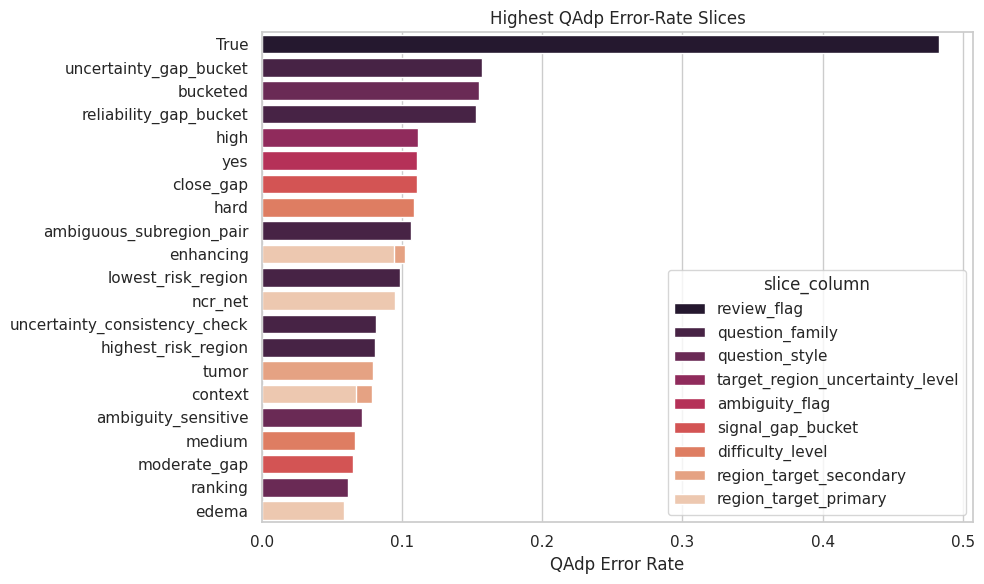

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/figures/phase03d_clean_qadp_error_concentration.png


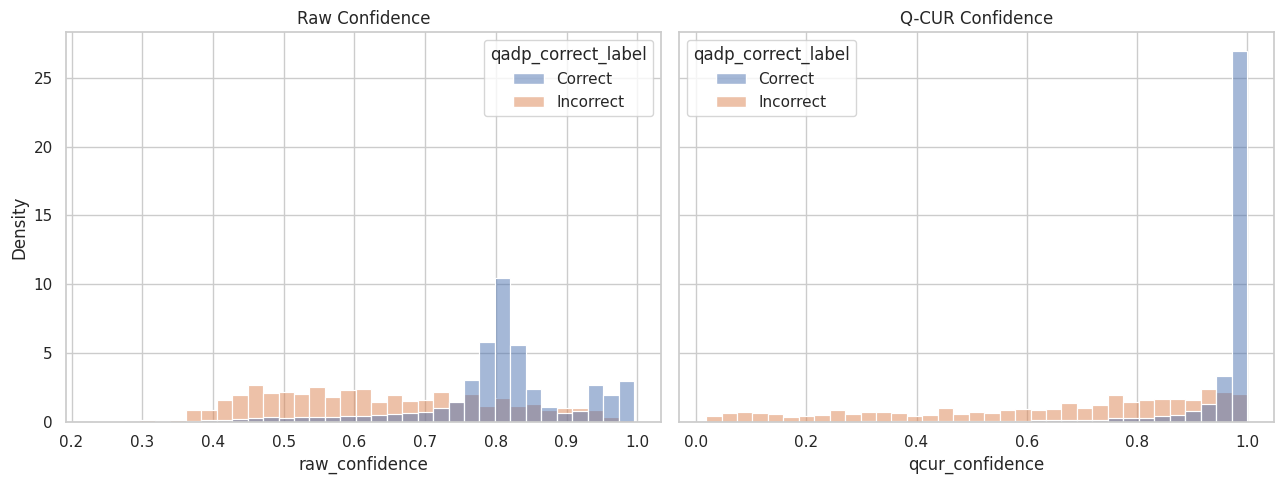

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/figures/phase03d_clean_confidence_correctness_histograms.png


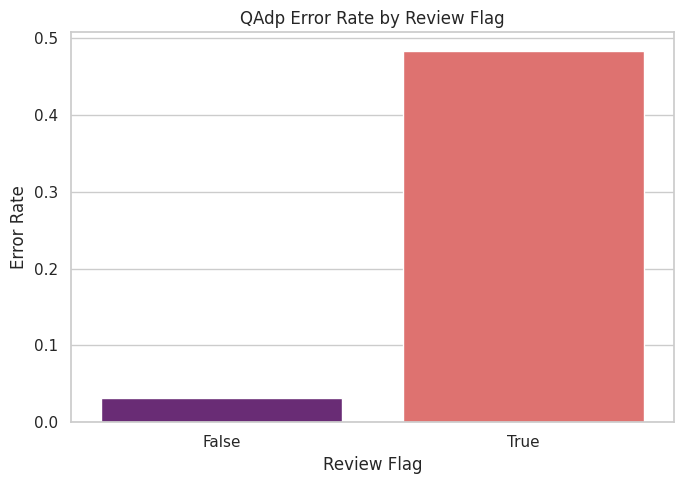

Saved figure: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline/figures/phase03d_clean_review_flag_error_rate.png


In [9]:
def save_current_figure(name: str) -> Path:
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=220, bbox_inches="tight")
    plt.show()
    print("Saved figure:", path)
    return path


plt.figure(figsize=(12, 5))
plot_overall = overall_table.sort_values("macro_f1", ascending=True)
sns.barplot(data=plot_overall, y="model_label", x="macro_f1", hue="policy_group", dodge=False, palette="Set2")
plt.title("Clean Phase 03D: Shortcut Baselines vs QAdp Macro-F1")
plt.xlabel("Macro-F1")
plt.ylabel("")
save_current_figure("phase03d_clean_shortcut_vs_qadp_macro_f1.png")

plt.figure(figsize=(10, 5))
gap_plot = shortcut_gap_by_slice.sort_values("qadp_minus_best_clean_safe_macro_f1").head(20)
sns.barplot(data=gap_plot, x="qadp_minus_best_clean_safe_macro_f1", y="slice_value", hue="slice_column", dodge=False, palette="Spectral")
plt.axvline(0, color="black", linewidth=1)
plt.title("Slices With Smallest QAdp Gain Over Best Clean-Safe Shortcut")
plt.xlabel("QAdp Macro-F1 - Best Clean-Safe Shortcut Macro-F1")
plt.ylabel("")
save_current_figure("phase03d_clean_lowest_qadp_shortcut_gap_slices.png")

plt.figure(figsize=(10, 6))
err_plot = error_concentration_table.head(25)
sns.barplot(data=err_plot, x="qadp_error_rate", y="slice_value", hue="slice_column", dodge=False, palette="rocket")
plt.title("Highest QAdp Error-Rate Slices")
plt.xlabel("QAdp Error Rate")
plt.ylabel("")
save_current_figure("phase03d_clean_qadp_error_concentration.png")

if {"raw_confidence", "qcur_confidence", "qadp_correct"}.issubset(prediction_join.columns):
    conf_plot = prediction_join.sample(min(15000, len(prediction_join)), random_state=RANDOM_STATE).copy()
    conf_plot["qadp_correct_label"] = conf_plot["qadp_correct"].map({True: "Correct", False: "Incorrect"})
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    sns.histplot(data=conf_plot, x="raw_confidence", hue="qadp_correct_label", bins=35, stat="density", common_norm=False, ax=axes[0])
    axes[0].set_title("Raw Confidence")
    sns.histplot(data=conf_plot, x="qcur_confidence", hue="qadp_correct_label", bins=35, stat="density", common_norm=False, ax=axes[1])
    axes[1].set_title("Q-CUR Confidence")
    save_current_figure("phase03d_clean_confidence_correctness_histograms.png")

if not review_flag_table.empty:
    plt.figure(figsize=(7, 5))
    sns.barplot(data=review_flag_table, x="review_flag", y="qadp_error_rate", hue="review_flag", dodge=False, legend=False, palette="magma")
    plt.title("QAdp Error Rate by Review Flag")
    plt.xlabel("Review Flag")
    plt.ylabel("Error Rate")
    save_current_figure("phase03d_clean_review_flag_error_rate.png")

## Final Report and Done Marker

In [10]:
qadp = overall_table.query("model_key == 'qadp_prugtm_hybrid_qcur'").iloc[0].to_dict()
best_clean_safe_shortcut = overall_table.query("policy_group == 'diagnostic_clean_safe'").sort_values("macro_f1", ascending=False).iloc[0].to_dict()
forbidden_shortcut = overall_table.query("policy_group == 'forbidden_audit_only'").sort_values("macro_f1", ascending=False).iloc[0].to_dict()

report = {
    "finished_at": now_string(),
    "phase": "Phase 03D clean-metadata QAdp shortcut, bias, and model audit",
    "dataset_path": str(BTUMQA_FULL_QA_PATH),
    "selected_evidence_path": str(SELECTED_EVIDENCE_PATH),
    "result_dir": str(RESULT_DIR),
    "selected_model": "QAdp-PRUGTM-Hybrid + Q-CUR",
    "qadp_overall": qadp,
    "best_clean_safe_shortcut": best_clean_safe_shortcut,
    "forbidden_audit_only_shortcut": forbidden_shortcut,
    "shortcut_gap_overall": shortcut_gap_table.to_dict(orient="records"),
    "review_flag_summary": review_flag_table.to_dict(orient="records") if not review_flag_table.empty else [],
    "paper_safe_interpretation": [
        "Shortcut baselines are diagnostic tests, not final VQA systems.",
        "Forbidden metadata baselines quantify leakage risk and must not be used as final model inputs.",
        "QAdp gains over clean-safe shortcuts support visual/uncertainty-aware value beyond QA priors when the gap is positive.",
        "Strong shortcut performance in a slice should be reported as residual benchmark bias or template prior risk.",
        "Review-flagged examples should be described as flagged for cautious interpretation, not as clinical recommendations.",
    ],
}
save_json(report, REPORT_DIR / "phase03d_clean_qadp_shortcut_model_audit_final_report.json")
save_json({"status": "complete", "finished_at": now_string(), "report": str(REPORT_DIR / "phase03d_clean_qadp_shortcut_model_audit_final_report.json")}, DONE_DIR / "phase03d_clean_qadp_shortcut_model_audit_complete.json")

print(json.dumps(report, indent=2)[:3500])

{
  "finished_at": "2026-05-13 17:31:26",
  "phase": "Phase 03D clean-metadata QAdp shortcut, bias, and model audit",
  "dataset_path": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3a_brats_vqa_dataset/dataset_btumqa_225k/btumqa_225k_qa_pairs.csv",
  "selected_evidence_path": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_5b_final_evaluation_ablation_calibration/btumqa_225k_clean_metadata_four_seeds_final_comparison/explanation_ready/selected_model_test_structured_evidence.csv",
  "result_dir": "/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_3d_qa_shortcut_bias_diagnostic_baselines/btumqa_225k_clean_metadata_shortcut_audit/qadp_prugtm_baseline",
  "selected_model": "QAdp-PRUGTM-Hybrid + Q-CUR",
  "qadp_overall": {
    "model_key": "qadp_prugtm_hybrid_qcur",
    "model_label": "QAdp-PRUGTM-Hybrid + Q-CU

## Quick Inspect Clean Phase 03D Artifacts

In [11]:
print("Tables:")
for path in sorted(TABLE_DIR.glob("*.csv")):
    print(" -", path.name)
print("\nPredictions:")
for path in sorted(PRED_DIR.glob("*.csv")):
    print(" -", path.name)
print("\nFigures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print(" -", path.name)
print("\nReports:")
for path in sorted(REPORT_DIR.glob("*.json")):
    print(" -", path.name)

Tables:
 - phase03d_clean_qadp_confidence_by_correctness.csv
 - phase03d_clean_qadp_error_concentration.csv
 - phase03d_clean_qadp_shortcut_gap_by_slice.csv
 - phase03d_clean_qadp_shortcut_gap_overall.csv
 - phase03d_clean_review_flag_usefulness.csv
 - phase03d_clean_shortcut_baseline_policy.csv
 - phase03d_clean_shortcut_vs_qadp_overall_metrics.csv
 - phase03d_clean_shortcut_vs_qadp_slice_metrics.csv

Predictions:
 - phase03d_clean_shortcut_baseline_predictions.csv

Figures:
 - phase03d_clean_confidence_correctness_histograms.png
 - phase03d_clean_lowest_qadp_shortcut_gap_slices.png
 - phase03d_clean_qadp_error_concentration.png
 - phase03d_clean_review_flag_error_rate.png
 - phase03d_clean_shortcut_vs_qadp_macro_f1.png

Reports:
 - phase03d_clean_qadp_audit_reproducibility_manifest.json
 - phase03d_clean_qadp_shortcut_model_audit_final_report.json
